In [1]:
import matplotlib.pyplot as plt
import numpy as np
from serial import Serial
import time
from collections import deque
import pandas as pd
from scipy.fft import fft, fftfreq
import math


In [2]:
GtoMS2 = 9.80665

accelscaler = 0.000061 * GtoMS2

filename = "mems_data.csv"

# UART Data

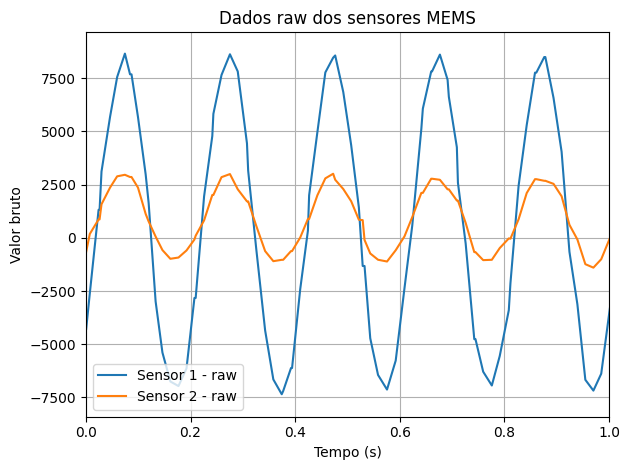

In [3]:

df = pd.read_csv(filename)

# plt.figure(figsize=(10, 5))

plt.plot(df["t_s"], df["raw_1"], label="Sensor 1 - raw")
plt.plot(df["t_s"], df["raw_2"], label="Sensor 2 - raw")

plt.xlim(0, 1)  # Limitar o eixo x para os primeiros 10 segundos

plt.xlabel("Tempo (s)")
plt.ylabel("Valor bruto")
plt.title("Dados raw dos sensores MEMS")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:

# Dados
signal = df["accel_1_ms2"].values
t = df["t_s"].values

# Intervalo de amostragem
dt = np.mean(np.diff(t))

# Número de pontos
N = len(signal)

# FFT
yf = fft(signal)
xf = fftfreq(N, dt)

# Plot apenas até a frequência de Nyquist
plt.figure(figsize=(10, 5))
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2]))
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT do sinal de aceleração - Sensor 1")
plt.grid(True)
plt.xlim(0, 50)  # Limitar para melhor visualização
plt.tight_layout()
plt.show()

KeyError: 'accel_1_ms2'

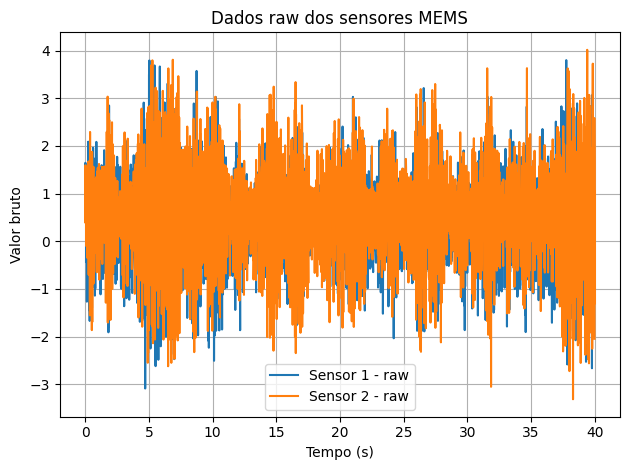

In [51]:

df = pd.read_csv(filename)

# plt.figure(figsize=(10, 5))

plt.plot(df["t_s"], df["raw_1"]*accelscaler, label="Sensor 1 - raw")
plt.plot(df["t_s"], df["raw_2"]*accelscaler, label="Sensor 2 - raw")

plt.xlabel("Tempo (s)")
plt.ylabel("Valor bruto")
plt.title("Dados raw dos sensores MEMS")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Bridge Data

In [7]:
df = pd.read_pickle("test.pkl")
df

,t_s,accel_1,accel_2,dac_1,dac_2,sample_counter,sample_valid,coeff_count_wf,coeff_count_ws,control_enable,config_dac1,config_dac2,pending_wf,pending_ws,ready_wf,ready_ws,overrun_wf,overrun_ws,raw_export,raw_data
0,0.000005,-6098,-931,3232,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,56857949190945885,418947484614912
1,0.001293,-5890,-904,3176,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,55872786786090104,418947484614912
2,0.002540,-5890,-873,3140,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,55239468088491159,418947484614912
3,0.003776,-5421,-755,3080,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,54183936956562701,418947484614912
4,0.005009,-5223,-807,3041,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,53497841713806553,418947484614912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8100,9.994073,-8038,-1462,3648,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,64176298458282570,418947484614912
8101,9.995307,-7985,-1455,3637,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,63982784415267409,418947484614912
8102,9.996540,-7925,-1490,3617,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,63630940698311214,418947484614912
8103,9.997773,-7897,-1475,3602,0,None,0,2000,2000,0,1,0,0,0,0,0,0,0,63367057909479997,418947484614912


        t_s  accel_1  accel_2  dac_1  dac_2 sample_counter  sample_valid  \
0  0.000005    -6098     -931   3232      0           None             0   
1  0.001293    -5890     -904   3176      0           None             0   
2  0.002540    -5890     -873   3140      0           None             0   
3  0.003776    -5421     -755   3080      0           None             0   
4  0.005009    -5223     -807   3041      0           None             0   

   coeff_count_wf  coeff_count_ws  control_enable  config_dac1  config_dac2  \
0            2000            2000               0            1            0   
1            2000            2000               0            1            0   
2            2000            2000               0            1            0   
3            2000            2000               0            1            0   
4            2000            2000               0            1            0   

   pending_wf  pending_ws  ready_wf  ready_ws  overrun_wf  overrun_w

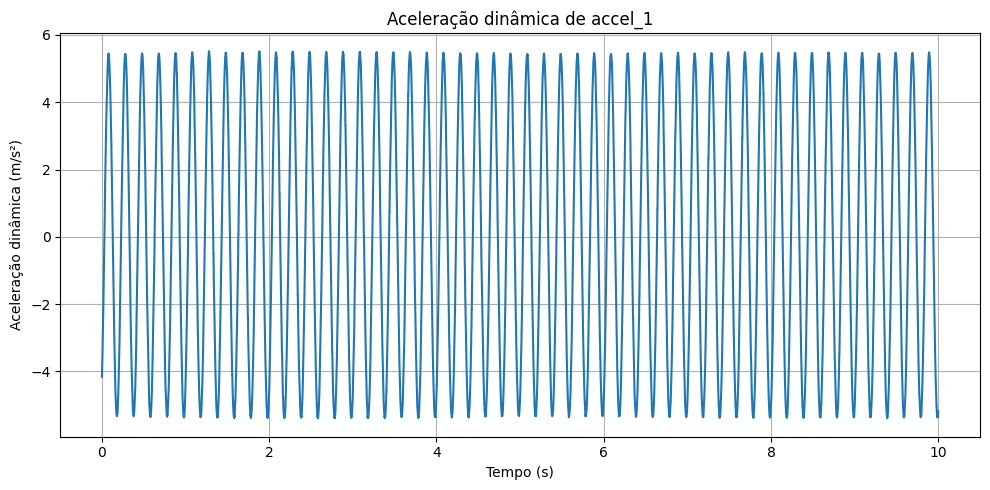

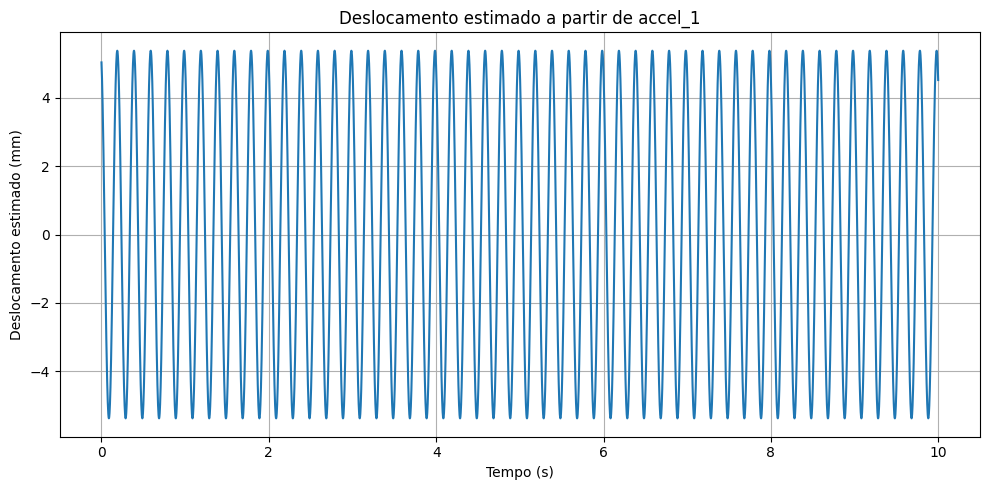

In [8]:
# =========================
# Carregar dados
# =========================
# df = pd.read_pickle("signal_3hz.pkl")
df = pd.read_pickle("test.pkl")

print(df.head())
print(df.columns)

# =========================
# Selecionar tempo e aceleração
# =========================
t = df["t_s"].to_numpy(dtype=float)
raw_accel_1 = df["accel_1"].to_numpy(dtype=float)

# =========================
# Conversão do LSM6DS3 ±2g
# 0.061 mg/LSB = 0.000061 g/LSB
# =========================
G = 9.80665
scale = 0.000061 * G

accel_1 = raw_accel_1 * scale  # m/s²

# Remove offset/DC, incluindo gravidade média
accel_1_dyn = accel_1 - np.mean(accel_1)

# =========================
# Estimar frequência dominante por FFT
# =========================
dt = np.median(np.diff(t))
fs = 1 / dt

freqs = np.fft.rfftfreq(len(accel_1_dyn), d=dt)
fft_mag = np.abs(np.fft.rfft(accel_1_dyn))

# Faixa onde espera-se a vibração
mask = (freqs > 0.2) & (freqs < 50)

f_dom = freqs[mask][np.argmax(fft_mag[mask])]

print(f"Frequência dominante estimada: {f_dom:.4f} Hz")

# =========================
# Ajuste senoidal da aceleração
# accel(t) = offset + A sin(wt) + B cos(wt)
# =========================
w = 2 * np.pi * f_dom

M = np.column_stack([
    np.ones_like(t),
    np.sin(w * t),
    np.cos(w * t)
])

coef, _, _, _ = np.linalg.lstsq(M, accel_1, rcond=None)

offset = coef[0]
A_sin = coef[1]
A_cos = coef[2]

accel_fit = A_sin * np.sin(w * t) + A_cos * np.cos(w * t)

# =========================
# Converter aceleração em deslocamento
#
# Para movimento senoidal:
# a(t) = -w² x(t)
# x(t) = -a(t) / w²
# =========================
disp_m = -accel_fit / (w**2)
disp_mm = disp_m * 1000

# Amplitudes
accel_amp = np.sqrt(A_sin**2 + A_cos**2)
disp_amp_m = accel_amp / (w**2)
disp_amp_mm = disp_amp_m * 1000
disp_pp_mm = 2 * disp_amp_mm

print(f"Amplitude da aceleração: {accel_amp:.4f} m/s²")
print(f"Amplitude do deslocamento: {disp_amp_mm:.4f} mm")
print(f"Deslocamento pico-a-pico: {disp_pp_mm:.4f} mm")

# =========================
# Plot da aceleração dinâmica
# =========================
plt.figure(figsize=(10, 5))
plt.plot(t, accel_1_dyn)
plt.xlabel("Tempo (s)")
plt.ylabel("Aceleração dinâmica (m/s²)")
plt.title("Aceleração dinâmica de accel_1")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Plot do deslocamento estimado
# =========================
plt.figure(figsize=(10, 5))
plt.plot(t, disp_mm)
plt.xlabel("Tempo (s)")
plt.ylabel("Deslocamento estimado (mm)")
plt.title("Deslocamento estimado a partir de accel_1")
plt.grid(True)
plt.tight_layout()
plt.show()

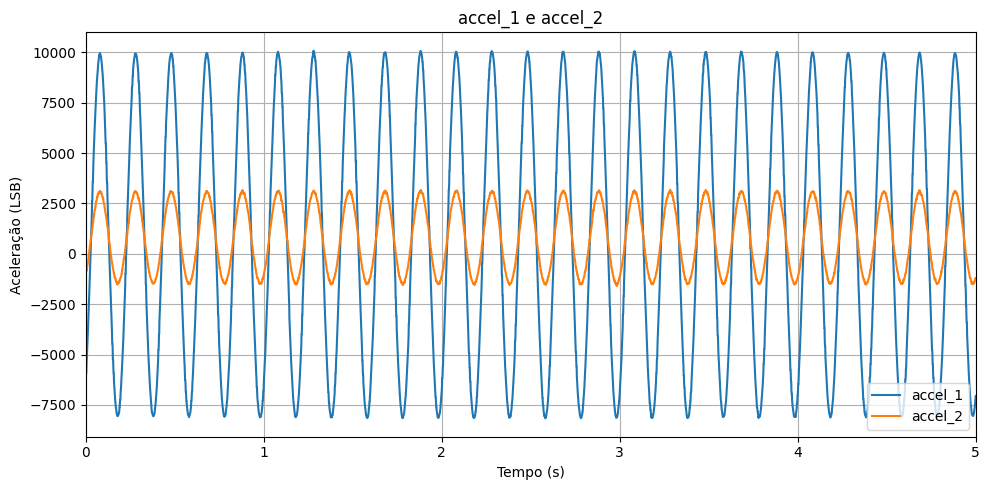

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["accel_1"], label="accel_1")
plt.plot(df["t_s"], df["accel_2"], label="accel_2")
plt.xlim(0, 5)  # Limitar o eixo x para os primeiros 10 segundos
plt.xlabel("Tempo (s)")
plt.ylabel("Aceleração (LSB)")
plt.title("accel_1 e accel_2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

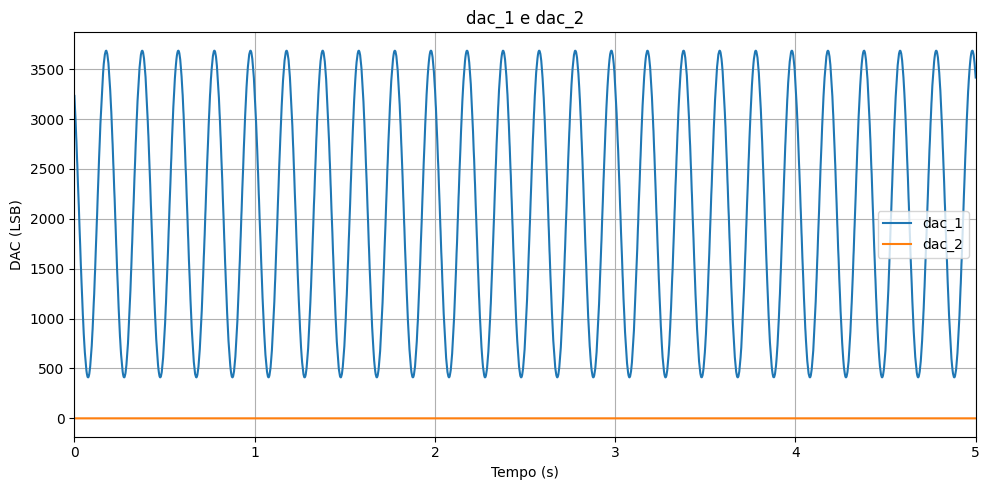

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df["t_s"], df["dac_1"], label="dac_1")
plt.plot(df["t_s"], df["dac_2"], label="dac_2")
plt.xlim(0, 5)  # Limitar o eixo x para os primeiros 10 segundos
plt.xlabel("Tempo (s)")
plt.ylabel("DAC (LSB)")
plt.title("dac_1 e dac_2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
np.mean(df["accel_1"])

np.float64(894.9852905123805)

In [20]:
df.head()

,t_s,accel_1,accel_2,dac_1,dac_2,sample_counter,sample_valid,config_dac1,config_dac2,pending_wf,pending_ws,ready_wf,ready_ws,overrun_wf,overrun_ws,raw_export,raw_data
0,0.000007,960,838,2048,1748,0,0,0,1,0,0,0,0,0,0,36036304684712774,1300414426762969088
1,0.001300,1092,808,2048,1700,0,0,0,1,0,0,0,0,0,0,36036098534933288,1300414426762969088
2,0.002571,1075,861,2048,1624,0,0,0,1,0,0,0,0,0,0,36035772116304733,1300414426762969088
3,0.003817,1115,845,2048,1576,0,0,0,1,0,0,0,0,0,0,36035565960495949,1300414426762969088
4,0.005066,1214,907,2048,1501,0,0,0,1,0,0,0,0,0,0,36035243844436875,1300414426762969088


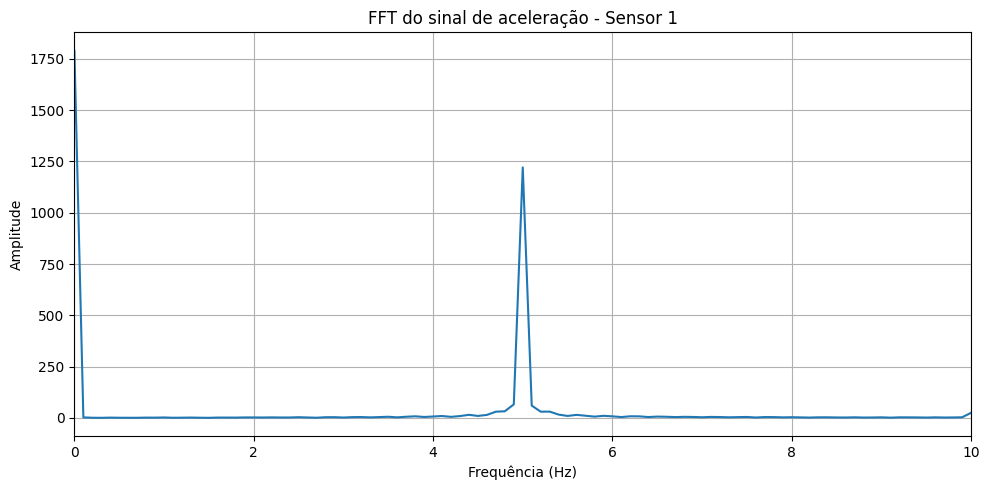

In [21]:

# Dados
signal = df["accel_1"].values
t = df["t_s"].values

# Intervalo de amostragem
dt = np.mean(np.diff(t))

# Número de pontos
N = len(signal)

# FFT
yf = fft(signal)
xf = fftfreq(N, dt)

# Plot apenas até a frequência de Nyquist
plt.figure(figsize=(10, 5))
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2]))
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT do sinal de aceleração - Sensor 1")
plt.grid(True)
plt.xlim(0, 10)  # Limitar para melhor visualização
plt.tight_layout()
plt.show()

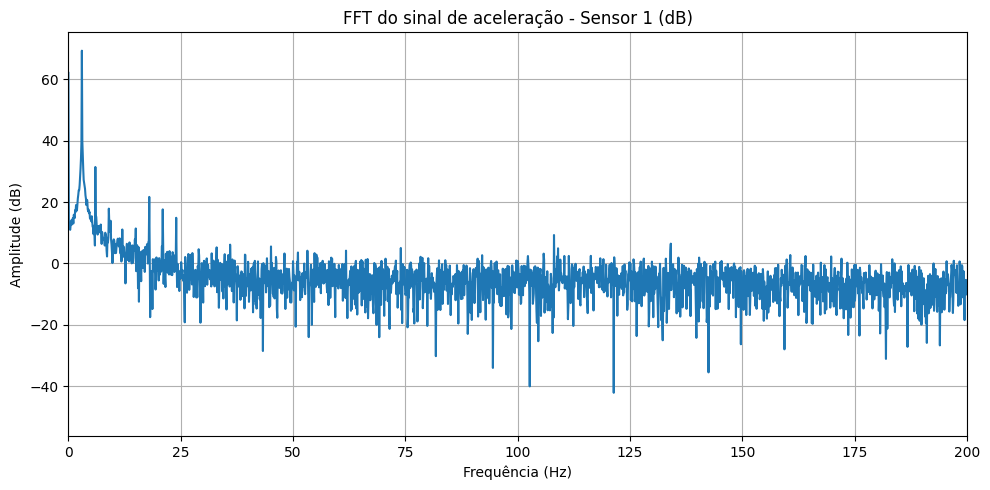

In [23]:
# Dados
signal = df["accel_1"].values
t = df["t_s"].values

# Intervalo de amostragem
dt = np.mean(np.diff(t))

# Número de pontos
N = len(signal)

# FFT
yf = fft(signal)
xf = fftfreq(N, dt)

# Converter amplitude para dB
# Usando 20*log10(amplitude) para amplitude
amplitude = 2.0/N * np.abs(yf[:N//2])
amplitude_db = 20 * np.log10(amplitude + 1e-10)  # evitar log(0)

# Plot em dB
plt.figure(figsize=(10, 5))
plt.plot(xf[:N//2], amplitude_db)
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude (dB)")
plt.title("FFT do sinal de aceleração - Sensor 1 (dB)")
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

## Noise Analysis

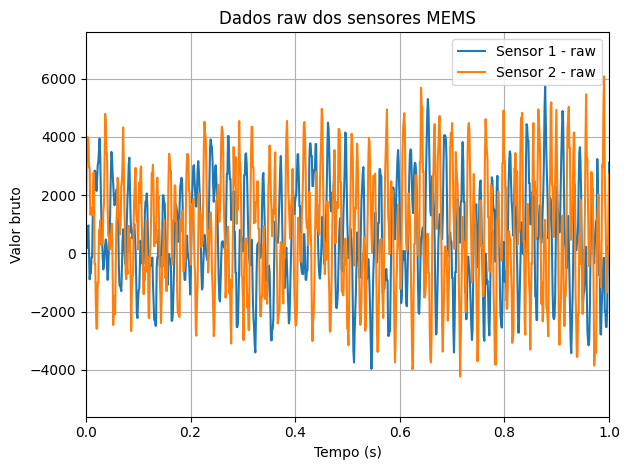

In [14]:

# filename = "noise.csv"
# df = pd.read_csv(filename)
df = pd.read_pickle("noise_v2.pkl")

# plt.figure(figsize=(10, 5))

plt.plot(df["t_s"], df["accel_1"], label="Sensor 1 - raw")
plt.plot(df["t_s"], df["accel_2"], label="Sensor 2 - raw")

plt.xlim(0, 1)  # Limitar o eixo x para os primeiros 10 segundos

plt.xlabel("Tempo (s)")
plt.ylabel("Valor bruto")
plt.title("Dados raw dos sensores MEMS")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

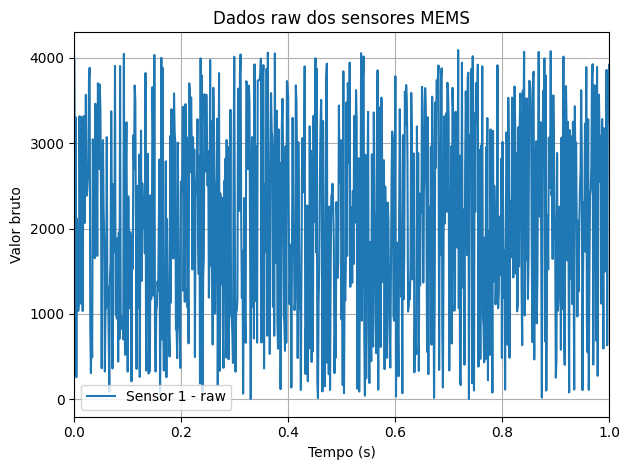

In [16]:

# filename = "noise.csv"
# df = pd.read_csv(filename)
df = pd.read_pickle("noise_v2.pkl")

# plt.figure(figsize=(10, 5))

plt.plot(df["t_s"], df["dac_signal"], label="Sensor 1 - raw")
# plt.plot(df["t_s"], df["accel_2"], label="Sensor 2 - raw")

plt.xlim(0, 1)  # Limitar o eixo x para os primeiros 10 segundos

plt.xlabel("Tempo (s)")
plt.ylabel("Valor bruto")
plt.title("Dados raw dos sensores MEMS")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

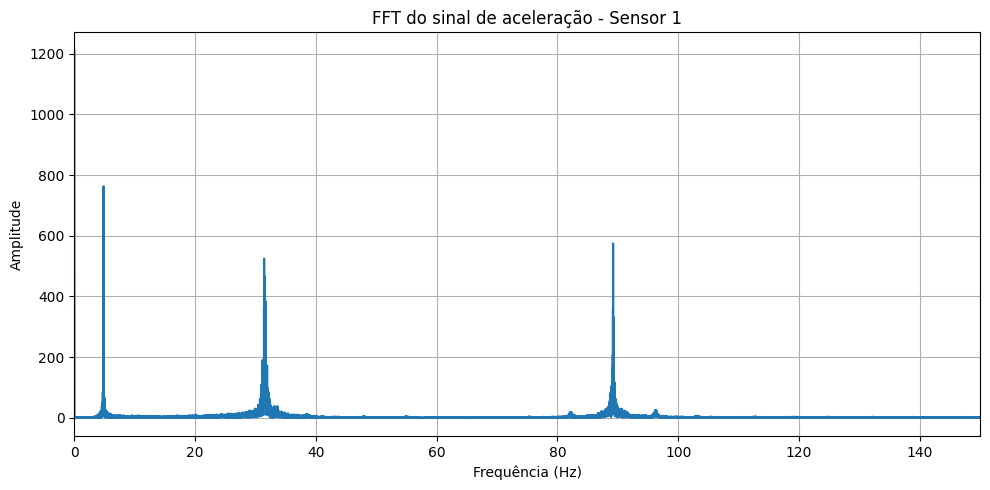

In [17]:

# Dados
signal = df["accel_1"].values
t = df["t_s"].values

# Intervalo de amostragem
dt = np.mean(np.diff(t))

# Número de pontos
N = len(signal)

# FFT
yf = fft(signal)
xf = fftfreq(N, dt)

# Plot apenas até a frequência de Nyquist
plt.figure(figsize=(10, 5))
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2]))
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT do sinal de aceleração - Sensor 1")
plt.grid(True)
plt.xlim(0, 150)  # Limitar para melhor visualização
plt.tight_layout()
plt.show()

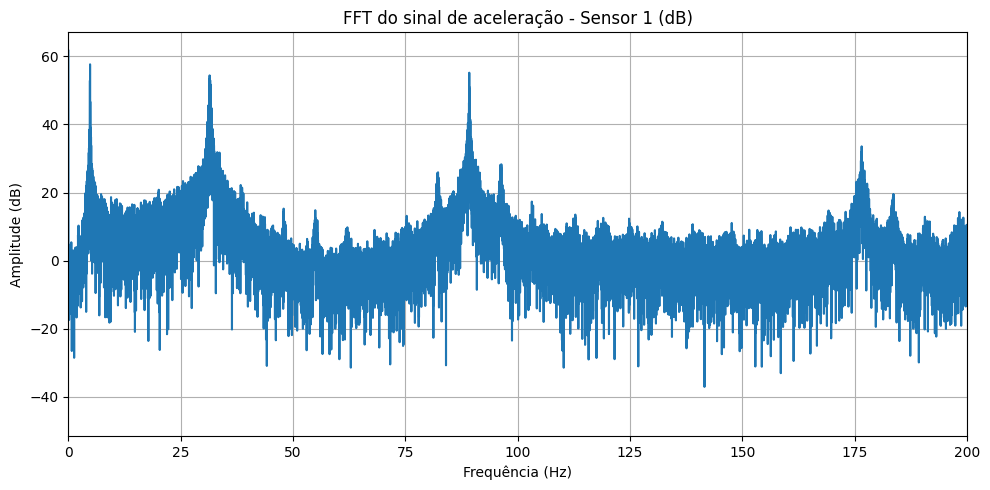

In [18]:
# Dados
signal = df["accel_1"].values
t = df["t_s"].values

# Intervalo de amostragem
dt = np.mean(np.diff(t))

# Número de pontos
N = len(signal)

# FFT
yf = fft(signal)
xf = fftfreq(N, dt)

# Converter amplitude para dB
# Usando 20*log10(amplitude) para amplitude
amplitude = 2.0/N * np.abs(yf[:N//2])
amplitude_db = 20 * np.log10(amplitude + 1e-10)  # evitar log(0)

# Plot em dB
plt.figure(figsize=(10, 5))
plt.plot(xf[:N//2], amplitude_db)
plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude (dB)")
plt.title("FFT do sinal de aceleração - Sensor 1 (dB)")
plt.grid(True)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

In [30]:
df.head()

,t_s,accel_1,accel_2,packed_u64,raw_u64,dac_signal
0,0.000006,-606,-1004,373622504468,373622504468,86
1,0.001250,-140,-460,6124614254132,6124614254132,1425
2,0.002458,511,-1173,7030895016811,7030895016811,1637
3,0.003657,1148,-488,15178489724440,15178489724440,3534
4,0.004857,2262,-64,9126953811904,9126953811904,2125


# Reading Rate

In [22]:
# df = pd.read_csv("teste.csv")

df = pd.read_pickle("noise.pkl")


dt_total = df["t_s"].iloc[-1] - df["t_s"].iloc[0]

mudancas_1 = (df["accel_1"].diff() != 0).sum() - 1
mudancas_2 = (df["accel_2"].diff() != 0).sum() - 1

fs_leitura = (len(df) - 1) / dt_total
fs_efetiva_1 = mudancas_1 / dt_total
fs_efetiva_2 = mudancas_2 / dt_total

print(f"Taxa de leitura Python/mm_bridge: {fs_leitura:.2f} Hz")
print(f"Taxa efetiva accel_1: {fs_efetiva_1:.2f} Hz")
print(f"Taxa efetiva accel_2: {fs_efetiva_2:.2f} Hz")

Taxa de leitura Python/mm_bridge: 843.04 Hz
Taxa efetiva accel_1: 767.97 Hz
Taxa efetiva accel_2: 768.77 Hz
